In [1]:
import seaborn as sns

diamonds = sns.load_dataset('diamonds')
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [7]:
x = diamonds.drop('price',axis=1)
y = diamonds['price']

from sklearn.ensemble import IsolationForest
import numpy as np
isolation = IsolationForest(random_state=42)

# 수치형 cols
num_cols = x.select_dtypes(np.number)
# 범주형
category_cols = x.describe(include='category').columns

from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
ordinary = OrdinalEncoder(categories=[[
    'Fair','Good','Very Good','Premium','Ideal'
    ]])
x['cut'] = ordinary.fit_transform(x[['cut']])

ordinary = OrdinalEncoder(categories=[[
    'J','I','H','G','F','E','D'
    ]])
x['color'] = ordinary.fit_transform(x[['color']])

ordinary = OrdinalEncoder(categories=[[
    'I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF'
    ]])
x['clarity'] = ordinary.fit_transform(x[['clarity']])
x.head()

# 파이프라인
# 모델선택(다양하게 테스트) linear, dtree, rfg
# 교차검증 - 성능이 어느정도 나오는지 확인
# 잘나오는 모델로 - 하이퍼 파라메터 튜닝

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
cvs = cross_val_score(RandomForestRegressor(),x_scaled,y,cv=5)


In [8]:
cvs.score()

AttributeError: 'numpy.ndarray' object has no attribute 'score'

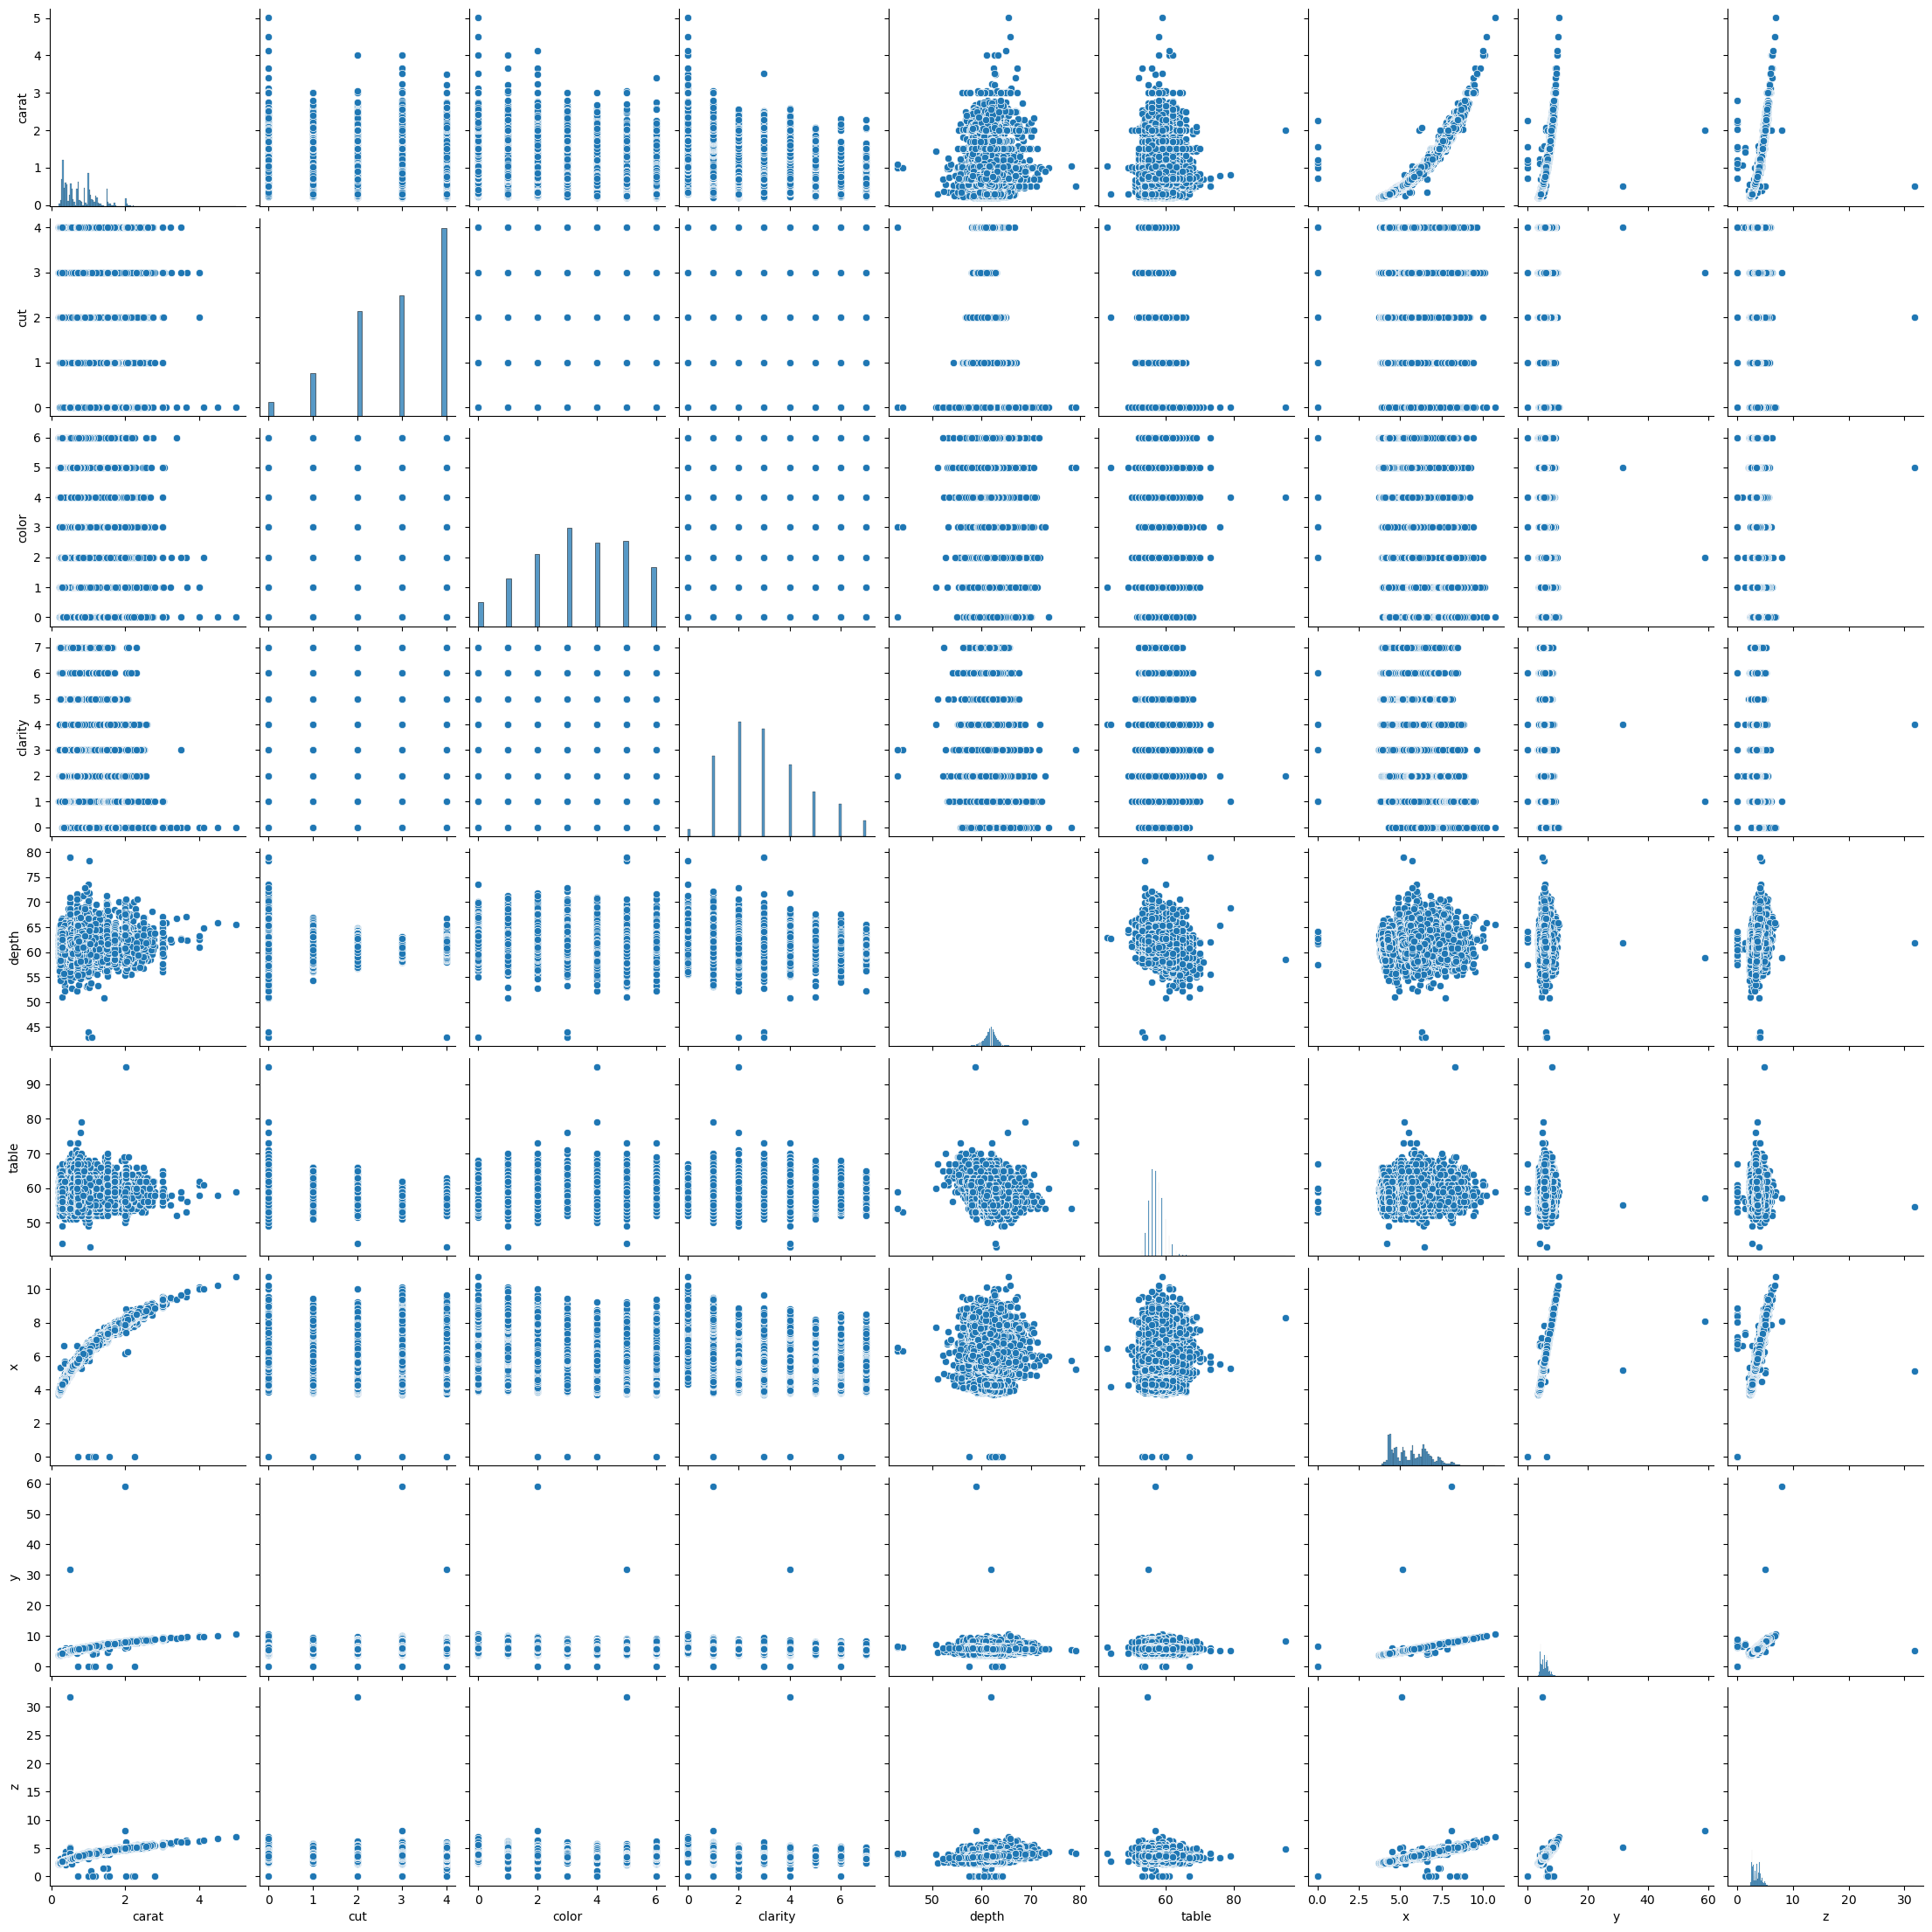

In [ ]:
sns.pairplot(x)

In [4]:
x.corr()

,carat,cut,color,clarity,depth,table,x,y,z
carat,1.000000,-0.134967,-0.291437,-0.352841,0.028224,0.181618,0.975094,0.951722,0.953387
cut,-0.134967,1.000000,0.020519,0.189175,-0.218055,-0.433405,-0.125565,-0.121462,-0.149323
color,-0.291437,0.020519,1.000000,-0.025631,-0.047279,-0.026465,-0.270287,-0.263584,-0.268227
clarity,-0.352841,0.189175,-0.025631,1.000000,-0.067384,-0.160327,-0.371999,-0.358420,-0.366952
depth,0.028224,-0.218055,-0.047279,-0.067384,1.000000,-0.295779,-0.025289,-0.029341,0.094924
table,0.181618,-0.433405,-0.026465,-0.160327,-0.295779,1.000000,0.195344,0.183760,0.150929
x,0.975094,-0.125565,-0.270287,-0.371999,-0.025289,0.195344,1.000000,0.974701,0.970772
y,0.951722,-0.121462,-0.263584,-0.358420,-0.029341,0.183760,0.974701,1.000000,0.952006
z,0.953387,-0.149323,-0.268227,-0.366952,0.094924,0.150929,0.970772,0.952006,1.000000
